In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [4]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

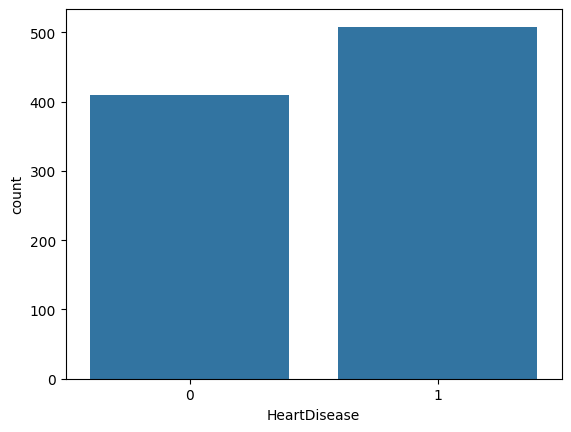

In [12]:
sns.countplot(x=df["HeartDisease"])

<Axes: xlabel='FastingBS', ylabel='count'>

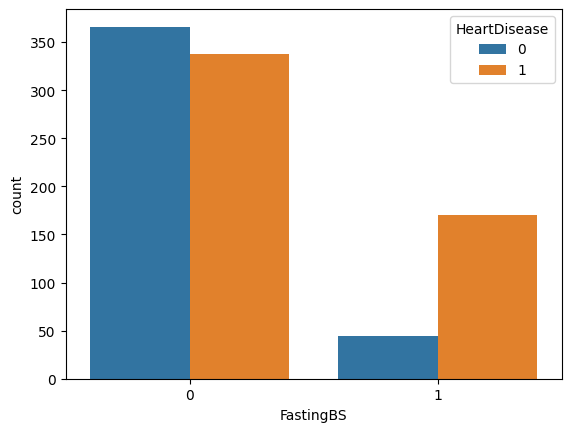

In [13]:
sns.countplot(x=df["FastingBS"],hue=df["HeartDisease"])

<Axes: xlabel='Sex', ylabel='count'>

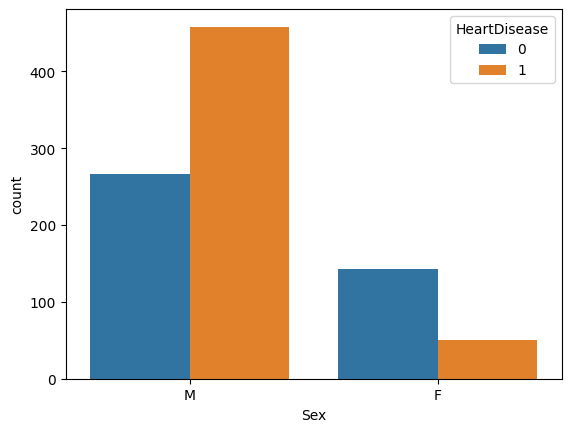

In [14]:
sns.countplot(x=df["Sex"],hue=df["HeartDisease"])

<Axes: xlabel='ChestPainType', ylabel='count'>

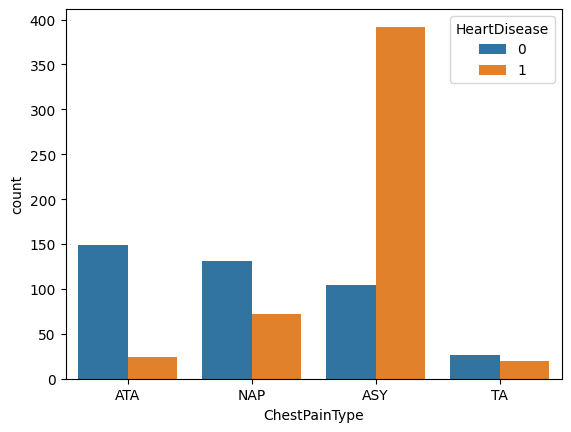

In [15]:
sns.countplot(x=df["ChestPainType"],hue=df["HeartDisease"])

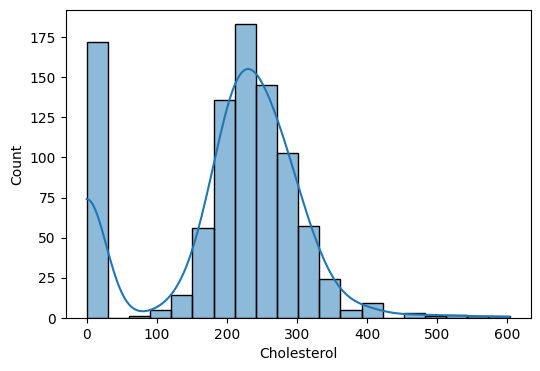

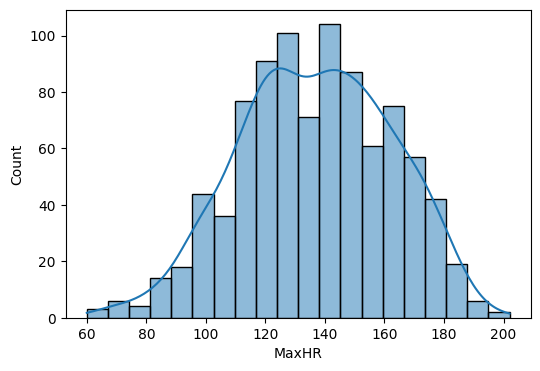

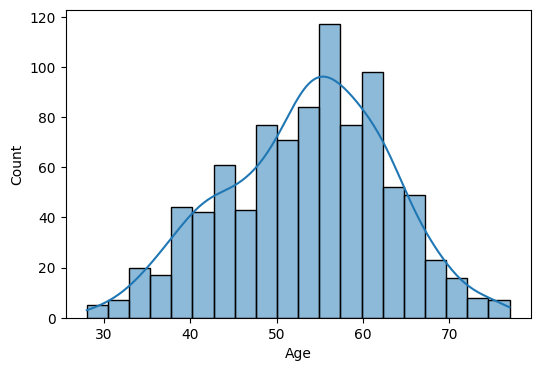

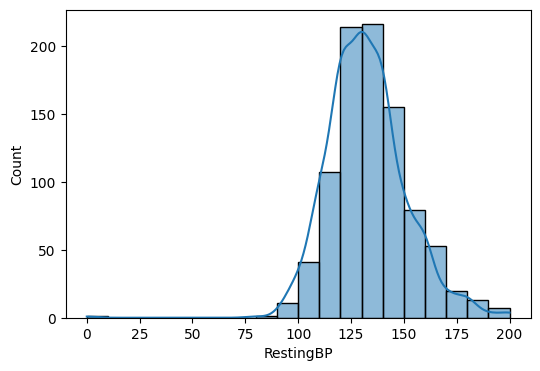

In [16]:
numeric_col=["Cholesterol","MaxHR","Age","RestingBP"]
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

In [17]:
df["Cholesterol"].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [18]:
ch_mean=df.loc[df["Cholesterol"]!=0,"Cholesterol"].mean()

In [19]:
df["Cholesterol"]=df["Cholesterol"].replace(0,ch_mean)
df["Cholesterol"]=df["Cholesterol"].round(2)

In [20]:
resting_bp_mean=df.loc[df["RestingBP"]!=0,"RestingBP"].mean()

In [21]:
df["RestingBP"]=df["RestingBP"].replace(0,resting_bp_mean)
df["RestingBP"]=df["RestingBP"].round(2)

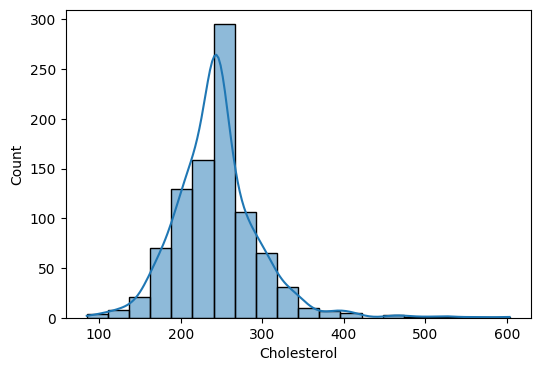

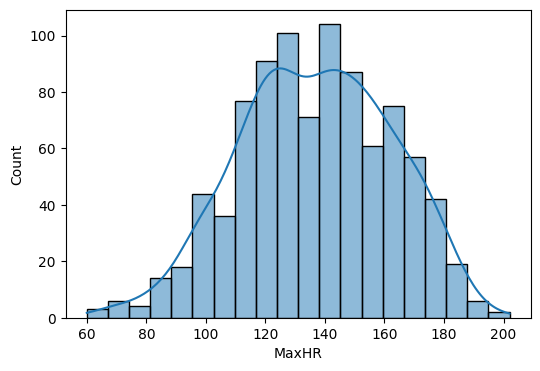

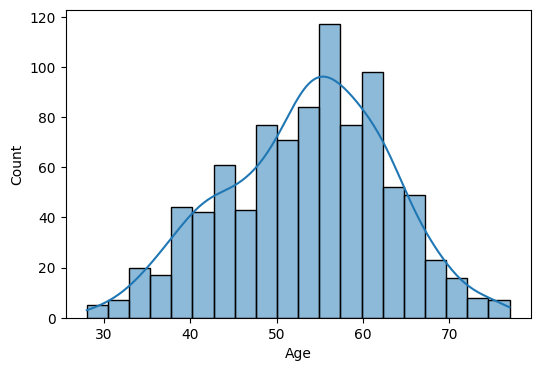

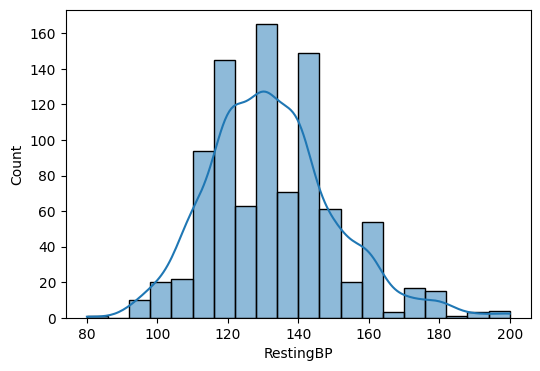

In [22]:
numeric_col=["Cholesterol","MaxHR","Age","RestingBP"]
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

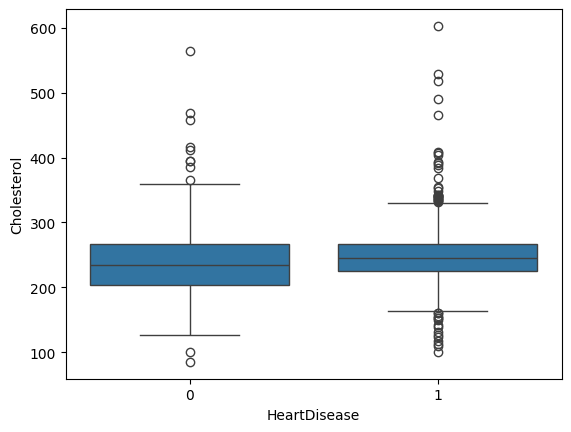

In [23]:
sns.boxplot(x="HeartDisease",y="Cholesterol",data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

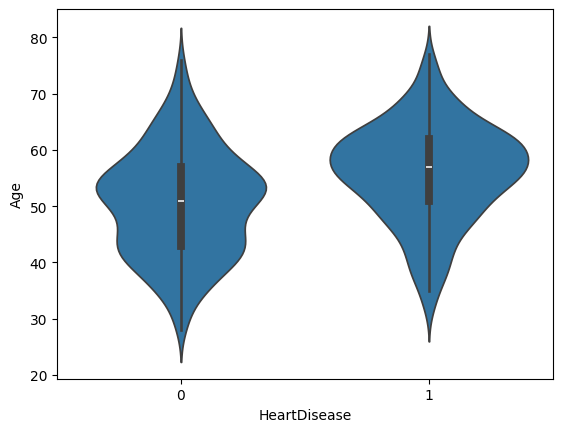

In [24]:
sns.violinplot(x="HeartDisease",y="Age",data=df)

<Axes: >

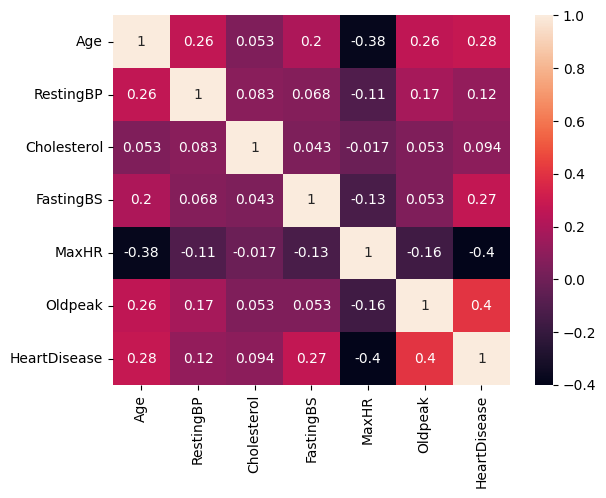

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Preprocessing 

In [26]:
df_encode=pd.get_dummies(df,drop_first=True)

In [27]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [28]:
df_encode=df_encode.astype(int)

In [29]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [30]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

# Feature Selection:

In [31]:
from scipy.stats import pearsonr
# Target variable
target = "HeartDisease"

# Features
selected_features = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'FastingBS',
    'MaxHR',
    'Oldpeak',
    'Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

# Calculate Pearson correlation with HeartDisease
correlations = {
    feature: pearsonr(df_encode[feature], df_encode[target])[0]
    for feature in selected_features
}

# Convert to DataFrame
correlations_df = pd.DataFrame(
    list(correlations.items()),
    columns=["feature", "Pearson Correlation"]
)
correlations_df.sort_values(
    by="Pearson Correlation",
    ascending=False
)


,feature,Pearson Correlation
13,ST_Slope_Flat,0.554134
12,ExerciseAngina_Y,0.494282
5,Oldpeak,0.392385
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117909
11,RestingECG_ST,0.102527
2,Cholesterol,0.092586
9,ChestPainType_TA,-0.054790


In [32]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Categorical / binary features
cat_features = [
    'Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

# Store results
chi2_results = {}

# Perform Chi-Square test
for col in cat_features:

    contingency = pd.crosstab(
        df_encode[col],
        df_encode["HeartDisease"]
    )

    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = (
        "Reject Null (Keep Feature)"
        if p_val < alpha
        else
        "Fail to Reject Null (Drop Feature)"
    )

    chi2_results[col] = {
        "chi2_statistic": chi2_stat,
        "p_value": p_val,
        "Decision": decision
    }

# Convert dictionary into DataFrame
chi2_df = pd.DataFrame(chi2_results).T

# Sort by p-value
chi2_df = chi2_df.sort_values(
    by="p_value"
)

chi2_df

,chi2_statistic,p_value,Decision
ST_Slope_Up,352.823905,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep Feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep Feature)
Sex_M,84.145101,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (Keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (Keep Feature)
RestingECG_Normal,7.327532,0.006791,Reject Null (Keep Feature)
ChestPainType_TA,2.273802,0.131577,Fail to Reject Null (Drop Feature)


In [33]:
final_features = [
    'ST_Slope_Up',
    'ST_Slope_Flat',
    'ExerciseAngina_Y',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'Sex_M',
    'RestingECG_ST',
    'RestingECG_Normal',
    'Oldpeak',
    'Age',
    'FastingBS',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    "HeartDisease"
]

In [34]:
final_df = df_encode[final_features]

In [35]:
final_df

,ST_Slope_Up,ST_Slope_Flat,ExerciseAngina_Y,ChestPainType_ATA,ChestPainType_NAP,Sex_M,RestingECG_ST,RestingECG_Normal,Oldpeak,Age,FastingBS,RestingBP,Cholesterol,MaxHR,HeartDisease
0,1,0,0,1,0,1,0,1,0,40,0,140,289,172,0
1,0,1,0,0,1,0,0,1,1,49,0,160,180,156,1
2,1,0,0,1,0,1,1,0,0,37,0,130,283,98,0
3,0,1,1,0,0,0,0,1,1,48,0,138,214,108,1
4,1,0,0,0,1,1,0,1,0,54,0,150,195,122,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,0,1,0,0,0,1,0,1,1,45,0,110,264,132,1
914,0,1,0,0,0,1,0,1,3,68,1,144,193,141,1
915,0,1,1,0,0,1,0,1,1,57,0,130,131,115,1
916,0,1,0,1,0,0,0,0,0,57,0,130,236,174,1


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [37]:
X=final_df.drop("HeartDisease",axis=1)
y=final_df["HeartDisease"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)



In [39]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [40]:
models={
    "logistic Regression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "Naive Byeas":GaussianNB(),
    "Decision Tress":DecisionTreeClassifier(),
    "SVM": SVC()
}

In [41]:
result=[]

In [42]:
for name, model in models.items():
    
    model.fit(x_train_scaled, y_train)
    
    y_pred = model.predict(x_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    
    f1 = f1_score(y_test, y_pred)
    
    result.append({
        "model": name,
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4)
    })

In [43]:
result_df = pd.DataFrame(result)
result_df

,model,Accuracy,F1 Score
0,logistic Regression,0.8515,0.8696
1,KNN,0.8482,0.8671
2,Naive Byeas,0.8548,0.8728
3,Decision Tress,0.7360,0.7561
4,SVM,0.8647,0.8845


In [44]:
import joblib
joblib.dump(models["SVM"],"SVM_heart.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']